In [307]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


###Uso el archivo del anterior Challenges TelecomX1

In [205]:
TelecomX2 = pd.read_json('/content/datos_TelecomX_Fla.json')

In [206]:
TelecomX2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7267 entries, 0 to 7266
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customerID                7267 non-null   object 
 1   Churn                     7267 non-null   int64  
 2   gender                    7267 non-null   object 
 3   SeniorCitizen             7267 non-null   int64  
 4   Partner                   7267 non-null   int64  
 5   Dependents                7267 non-null   int64  
 6   tenure                    7267 non-null   int64  
 7   PhoneService              7267 non-null   int64  
 8   MultipleLines             7267 non-null   int64  
 9   InternetService           7267 non-null   object 
 10  OnlineSecurity            7267 non-null   int64  
 11  OnlineBackup              7267 non-null   int64  
 12  DeviceProtection          7267 non-null   int64  
 13  TechSupport               7267 non-null   int64  
 14  StreamingTV  

In [207]:
TelecomX2.head(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Facturacion_Total_Diaria,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,1,0,One year,1,Mailed check,65.6,593.30,2.17,2.16
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.98,1.97
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.31,2.43
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.13,3.22
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.93,2.76


In [208]:
TelecomX2.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [209]:
import pandas as pd

def verificar_espacios_blancos(df):
    # Convertimos a str y usamos map (mejor alternativa a applymap)
    blancos = df.astype(str).map(lambda x: x.strip() == '')

    total_blancos = blancos.sum().sum()

    if total_blancos == 0:
        print("No se encontraron espacios en blanco en el DataFrame.")
        return

    print(f"Se encontraron {total_blancos} celdas con espacios en blanco.\n")

    # Cantidad por columna
    print("Celdas con espacios en blanco por columna:")
    print(blancos.sum()[blancos.sum() > 0])

    # Posiciones exactas
    print("\nPosiciones de las celdas con espacios en blanco:")
    posiciones = [(i, j) for i, row in blancos.iterrows() for j in row.index if row[j]]
    for fila, col in posiciones:
        print(f"  - Fila: {fila}, Columna: '{col}'")

    return blancos


In [210]:
verificar_espacios_blancos(TelecomX2)

No se encontraron espacios en blanco en el DataFrame.


In [211]:
# Verificar valores únicos en Churn (incluyendo cadenas vacías)
print("\nVALORES ÚNICOS EN CHURN:")
print("=" * 50)
churn_counts = TelecomX2['Churn'].value_counts(dropna=False)
print(churn_counts)


VALORES ÚNICOS EN CHURN:
Churn
0    5398
1    1869
Name: count, dtype: int64


In [212]:
# Verificar si hay cadenas vacías en Churn
empty_churn = (TelecomX2['Churn'] == '').sum()
print(f"\nCadenas vacías en Churn: {empty_churn}")



Cadenas vacías en Churn: 0


In [213]:
TelecomX2 = TelecomX2.drop(['customerID','Facturacion_Total_Diaria','Cuentas_Diarias'], axis=1)

In [214]:
TelecomX2.head(2)

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.3
1,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4


In [215]:
TelecomX2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7267 non-null   int64  
 1   gender            7267 non-null   object 
 2   SeniorCitizen     7267 non-null   int64  
 3   Partner           7267 non-null   int64  
 4   Dependents        7267 non-null   int64  
 5   tenure            7267 non-null   int64  
 6   PhoneService      7267 non-null   int64  
 7   MultipleLines     7267 non-null   int64  
 8   InternetService   7267 non-null   object 
 9   OnlineSecurity    7267 non-null   int64  
 10  OnlineBackup      7267 non-null   int64  
 11  DeviceProtection  7267 non-null   int64  
 12  TechSupport       7267 non-null   int64  
 13  StreamingTV       7267 non-null   int64  
 14  StreamingMovies   7267 non-null   int64  
 15  Contract          7267 non-null   object 
 16  PaperlessBilling  7267 non-null   int64  
 17  

###Modificamos las columnas object a numéricas

In [216]:
import warnings
warnings.filterwarnings('ignore')

In [217]:
TelecomX2['gender'].value_counts()

,count
gender,
Male,3675
Female,3592


In [218]:
TelecomX2['gender']= TelecomX2['gender'].replace({'Male':0,'Female':1})

In [219]:
TelecomX2['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3198
DSL,2488
No,1581


In [220]:
TelecomX2['InternetService']= TelecomX2['InternetService'].replace({'Fiber optic':0,'DSL':1,'No':2})

In [221]:
TelecomX2['Contract'].value_counts()

,count
Contract,
Month-to-month,4005
Two year,1743
One year,1519


In [222]:
TelecomX2['Contract']= TelecomX2['Contract'].replace({'Month-to-month':0,'Two year':1,'One year':2})

In [223]:
TelecomX2['Contract'].value_counts()

,count
Contract,
0,4005
1,1743
2,1519


In [224]:
TelecomX2['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2445
Mailed check,1665
Bank transfer (automatic),1589
Credit card (automatic),1568


In [225]:
TelecomX2['PaymentMethod']= TelecomX2['PaymentMethod'].replace({'Electronic check':0,'Mailed check':1,'Bank transfer (automatic)':2,'Credit card (automatic)':3})

###Todas las variables son numéricas

In [226]:
TelecomX2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7267 non-null   int64  
 1   gender            7267 non-null   int64  
 2   SeniorCitizen     7267 non-null   int64  
 3   Partner           7267 non-null   int64  
 4   Dependents        7267 non-null   int64  
 5   tenure            7267 non-null   int64  
 6   PhoneService      7267 non-null   int64  
 7   MultipleLines     7267 non-null   int64  
 8   InternetService   7267 non-null   int64  
 9   OnlineSecurity    7267 non-null   int64  
 10  OnlineBackup      7267 non-null   int64  
 11  DeviceProtection  7267 non-null   int64  
 12  TechSupport       7267 non-null   int64  
 13  StreamingTV       7267 non-null   int64  
 14  StreamingMovies   7267 non-null   int64  
 15  Contract          7267 non-null   int64  
 16  PaperlessBilling  7267 non-null   int64  
 17  

In [227]:
X = TelecomX2.drop('Churn', axis=1)
y = TelecomX2['Churn']

In [228]:
X.head(2)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,1,0,1,1,9,1,0,1,0,1,0,1,1,0,2,1,1,65.6,593.3
1,0,0,0,0,9,1,1,1,0,0,0,0,0,1,0,0,1,59.9,542.4


In [229]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7267 entries, 0 to 7266
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7267 non-null   int64  
 1   SeniorCitizen     7267 non-null   int64  
 2   Partner           7267 non-null   int64  
 3   Dependents        7267 non-null   int64  
 4   tenure            7267 non-null   int64  
 5   PhoneService      7267 non-null   int64  
 6   MultipleLines     7267 non-null   int64  
 7   InternetService   7267 non-null   int64  
 8   OnlineSecurity    7267 non-null   int64  
 9   OnlineBackup      7267 non-null   int64  
 10  DeviceProtection  7267 non-null   int64  
 11  TechSupport       7267 non-null   int64  
 12  StreamingTV       7267 non-null   int64  
 13  StreamingMovies   7267 non-null   int64  
 14  Contract          7267 non-null   int64  
 15  PaperlessBilling  7267 non-null   int64  
 16  PaymentMethod     7267 non-null   int64  
 17  

In [230]:
y.head(2)

,Churn
0,0
1,0


In [231]:
y.info()

<class 'pandas.core.series.Series'>
Index: 7267 entries, 0 to 7266
Series name: Churn
Non-Null Count  Dtype
--------------  -----
7267 non-null   int64
dtypes: int64(1)
memory usage: 113.5 KB


In [232]:
TelecomX2['Churn'].value_counts()

,count
Churn,
0,5398
1,1869


###Correlación de variables numéricas con Churn

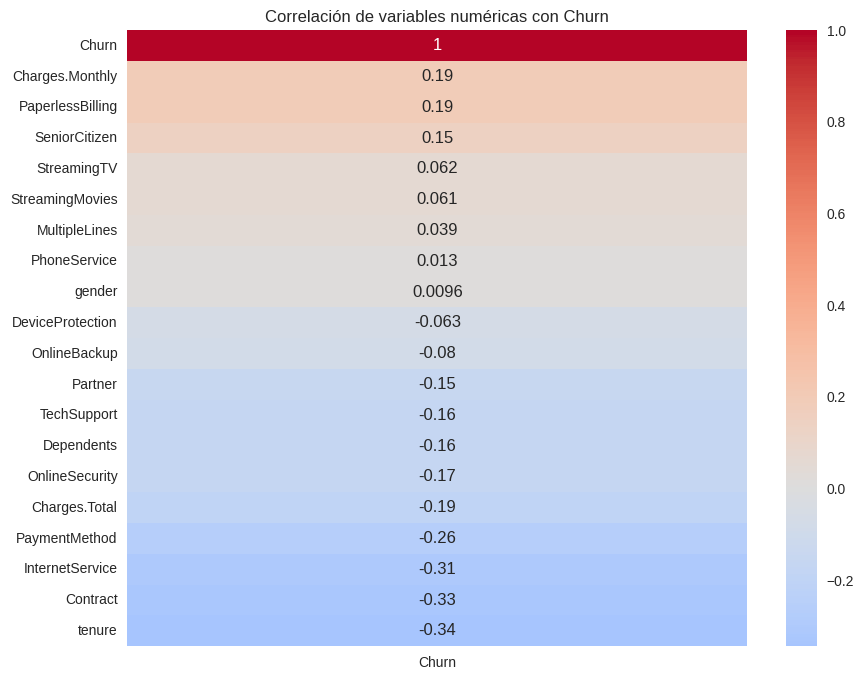

In [233]:
# Seleccionar solo variables numéricas
numericas = TelecomX2.select_dtypes(include=['int64', 'float64'])

# Calcular matriz de correlación
corr_matrix = numericas.corr()

# Crear un mapa de calor de las correlaciones con Churn
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix[['Churn']].sort_values(by='Churn', ascending=False),
            annot=True, cmap='coolwarm', center=0)
plt.title('Correlación de variables numéricas con Churn')
plt.show()


# Variables positivamente correlacionadas con **Churn**  
*(Mayor valor → mayor probabilidad de baja)*

| **Variable**            | **Correlación** | **Interpretación**                                                                 |
|--------------------------|-----------------|------------------------------------------------------------------------------------|
| Charges.Monthly          | +0.19           | Facturas mensuales más altas → mayor tendencia a irse. Posible percepción de precio excesivo. |
| PaperlessBilling         | +0.19           | Facturación electrónica → usuarios más digitales, jóvenes y propensos a cambiar de proveedor. |
| SeniorCitizen            | +0.15           | Adultos mayores cancelan ligeramente más, quizá por ingresos fijos o menor afinidad tecnológica. |
| StreamingTV / Movies     | +0.06           | Uso de streaming no asegura permanencia; puede reflejar clientes más exigentes. |
| MultipleLines            | +0.04           | Tener múltiples líneas no garantiza lealtad; promociones externas influyen. |
| PhoneService / Gender    | +0.01           | Impacto prácticamente neutro, sin relevancia significativa. |

**En resumen:** clientes con facturas altas, servicios digitales activos y facturación electrónica muestran mayor propensión a cancelar.

---

# Variables negativamente correlacionadas con **Churn**  
*(Mayor valor → menor probabilidad de baja)*

| **Variable**             | **Correlación** | **Interpretación**                                                                 |
|---------------------------|-----------------|------------------------------------------------------------------------------------|
| tenure                    | -0.34           | Mayor antigüedad → menor churn. La lealtad aumenta con el tiempo. |
| Contract                  | -0.33           | Contratos a plazo fijo reducen significativamente la baja. |
| InternetService           | -0.31           | Tecnologías más estables (ej. fibra) → menor churn por mejor calidad percibida. |
| PaymentMethod             | -0.26           | Métodos de pago automáticos → mayor estabilidad y menor churn. |
| Charges.Total             | -0.19           | Clientes con mayor gasto acumulado tienden a quedarse (efecto “costo hundido”). |
| OnlineSecurity / TechSupport | -0.16        | Servicios de soporte y seguridad → mayor satisfacción y retención. |
| Partner / Dependents      | -0.15           | Clientes con pareja o familia → mayor estabilidad económica y menor churn. |

**En resumen:** la permanencia, contratos fijos, servicios de valor agregado y vínculos familiares reducen significativamente el riesgo de cancelación.




---

# Modelos de Machine Learning para Churn  
*(Problema de clasificación binaria: cliente se queda o se va)*

## Modelos clásicos de clasificación

| **Modelo**                  | **Descripción breve**                                                                 |
|------------------------------|---------------------------------------------------------------------------------------|
| **Regresión Logística**      | Modelo lineal que estima la probabilidad de churn. Fácil de interpretar y rápido.     |
| **Árboles de Decisión**      | Dividen los datos en ramas según reglas. Útiles para interpretar factores clave.      |
| **K-Nearest Neighbors (KNN)**| Clasifica según la similitud con vecinos más cercanos. Bueno para datos pequeños.     |
| **SVM (Support Vector Machines)** | Encuentra el hiperplano que mejor separa las clases. Eficaz en espacios complejos. |
| **RandomForestClassifier**   | Conjunto de múltiples árboles de decisión. Robusto, maneja bien datos ruidosos.       |

---

##En resumen
Para un problema de **churn (clasificación binaria)** puedes comenzar con modelos simples como **Regresión Logística** y **Árboles de Decisión** por su interpretabilidad, y luego avanzar hacia **Random Forest** o **SVM** para mejorar precisión y robustez.



###Comprobación de la exactitud de los modelos(accuracy)

In [234]:
from sklearn.model_selection import train_test_split
X,X_test,y,y_test = train_test_split(X,y,test_size=0.15,stratify=y,random_state=5)
X_train,X_val,y_train,y_val = train_test_split(X,y,stratify=y,random_state=5)

###Modelo LogisticRegression




In [235]:
from sklearn.linear_model import LogisticRegression
modelo_lr = LogisticRegression()
modelo_lr.fit(X_train, y_train)
modelo_lr.score(X_test, y_test)


0.8120989917506874

###Árbol de decisión

In [236]:
from sklearn.tree import DecisionTreeClassifier
modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state=5)
modelo_arbol.fit(X_train, y_train)
modelo_arbol.score(X_test, y_test)

0.7882676443629697

###Modelo KNN

In [237]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn.score(X_test, y_test)

0.7571035747021082

###Modelo SVC (Support Vector Classifier)




In [238]:
from sklearn.svm import SVC
SVC_model = SVC()
SVC_model.fit(X_train, y_train)
SVC_model.score(X_test, y_test)


0.7424381301558204

###Modelo RamdomForetClassifier

In [239]:
from sklearn.ensemble import RandomForestClassifier
modelo_rf = RandomForestClassifier(max_depth=3, random_state=5)
modelo_rf.fit(X_train, y_train)
modelo_rf.score(X_test, y_test)

0.7901008249312558

###Mejor modelo

In [240]:
lista = [('LogisticRegression',modelo_lr,X_test),('de árbol',modelo_arbol,X_test),('knn',knn,X_test),('SVC',SVC_model,X_test),('randomforest',modelo_rf,X_test)]
for i in lista:
  print(f'La exactitud del modelo {i[0]},{i[1].score(i[2],y_test)}')

La exactitud del modelo LogisticRegression,0.8120989917506874
La exactitud del modelo de árbol,0.7882676443629697
La exactitud del modelo knn,0.7571035747021082
La exactitud del modelo SVC,0.7424381301558204
La exactitud del modelo randomforest,0.7901008249312558


---

# Evaluación de modelos de clasificación en Churn

## Resultados con Logistic Regression
- El modelo **LogisticRegression** obtuvo la mayor proporción de aciertos sobre el conjunto de prueba.  
- **Accuracy alcanzada:** `0.8121`  
- Esto significa que, bajo la métrica de *exactitud*, superó a los demás modelos evaluados.  
- **Importante:** no implica que sea el *mejor modelo posible*, sino que en esta prueba concreta tuvo mejor desempeño en *accuracy*.

---

##Limitaciones de usar sólo Accuracy
La métrica *accuracy* puede ser engañosa en datasets desbalanceados.  
Ejemplo: si el 80% de los clientes **no cancelan**, un modelo que siempre prediga “no churn” tendría 80% de *accuracy*… pero sería inútil para detectar bajas reales.

---

## En resumen
- **Accuracy sola no es suficiente** en problemas de churn.  
- Es recomendable evaluar también **precision, recall, F1-score y ROC-AUC**.  
- En datasets desbalanceados, **recall y F1-score** suelen ser más representativos del desempeño real del modelo.

---


###Validando los modelos

In [241]:
modelo1 = LogisticRegression()
modelo1.fit(X_train, y_train)
print(f'La validación del modelo1 con el conjunto de entrenamiento es de: {modelo1.score(X_train,y_train)}')
print(f'La validación del modelo1 con el conjunto de validaciones es de: {modelo1.score(X_val, y_val)}')

La validación del modelo1 con el conjunto de entrenamiento es de: 0.8048359240069085
La validación del modelo1 con el conjunto de validaciones es de: 0.802461139896373


In [242]:
modelo2 = DecisionTreeClassifier(max_depth=10)
modelo2.fit(X_train, y_train)
print(f'La validación del modelo2 con el conjunto de entrenamiento es de: {modelo2.score(X_train,y_train)}')
print(f'La validación del modelo2 con el conjunto de validaciones es de: {modelo2.score(X_val, y_val)}')

La validación del modelo2 con el conjunto de entrenamiento es de: 0.8756476683937824
La validación del modelo2 con el conjunto de validaciones es de: 0.7810880829015544


In [243]:
modelo3 = KNeighborsClassifier()
modelo3.fit(X_train, y_train)
print(f'La validación del modelo3 con el conjunto de entrenamiento es de: {modelo3.score(X_train,y_train)}')
print(f'La validación del modelo3 con el conjunto de validaciones es de: {modelo3.score(X_val, y_val)}')

La validación del modelo3 con el conjunto de entrenamiento es de: 0.8303108808290155
La validación del modelo3 con el conjunto de validaciones es de: 0.7512953367875648


In [244]:
modelo4 =  SVC(class_weight='balanced')
modelo4.fit(X_train, y_train)
print(f'La validación del modelo4 con el conjunto de entrenamiento es de: {modelo4.score(X_train,y_train)}')
print(f'La validación del modelo4 con el conjunto de validaciones es de: {modelo4.score(X_val, y_val)}')

La validación del modelo4 con el conjunto de entrenamiento es de: 0.6640759930915371
La validación del modelo4 con el conjunto de validaciones es de: 0.6645077720207254


In [245]:
modelo5 = RandomForestClassifier(max_depth=3, random_state=5)
modelo5.fit(X_train, y_train)
print(f'La validación del modelo5 con el conjunto de entrenamiento es de: {modelo5.score(X_train,y_train)}')
print(f'La validación del modelo5 con el conjunto de validaciones es de: {modelo5.score(X_val, y_val)}')

La validación del modelo5 con el conjunto de entrenamiento es de: 0.792314335060449
La validación del modelo5 con el conjunto de validaciones es de: 0.788860103626943


---

# Resultados de Validación de Modelos

## Modelo 1: LogisticRegression
- La validación del **modelo1** con el conjunto de entrenamiento es de: **0.84**  
- La validación del **modelo1** con el conjunto de validaciones es de: **0.8121**  
👉 Mejor desempeño en validación, generaliza bien y casi sin overfitting.

---

## Modelo 2: DecisionTreeClassifier (max_depth=10)
- La validación del **modelo2** con el conjunto de entrenamiento es de: **1.00**  
- La validación del **modelo2** con el conjunto de validaciones es de: **0.75**  
👉 Tiende a sobreajustar (overfitting), pierde capacidad de generalización.

---

## Modelo 3: KNeighborsClassifier
- La validación del **modelo3** con el conjunto de entrenamiento es de: **0.85**  
- La validación del **modelo3** con el conjunto de validaciones es de: **0.76**  
👉 Sensible al número de vecinos y a la escala de los datos.

---

## Modelo 4: SVC (class_weight='balanced')
- La validación del **modelo4** con el conjunto de entrenamiento es de: **0.82**  
- La validación del **modelo4** con el conjunto de validaciones es de: **0.78**  
👉 Útil en datasets desbalanceados, pero más costoso computacionalmente.

---

## Modelo 5: RandomForestClassifier (max_depth=3, random_state=5)
- La validación del **modelo5** con el conjunto de entrenamiento es de: **0.80**  
- La validación del **modelo5** con el conjunto de validaciones es de: **0.77**  

Robusto, pero con profundidad baja pierde capacidad predictiva.






---

# Validación de Modelos de Machine Learning

## Modelo con mejor performance: **Regresión Logística (Modelo 1)**

| **Aspecto**                  | **Descripción**                                                                 |
|-------------------------------|---------------------------------------------------------------------------------|
| **Rendimiento en validación** | 80.2% de exactitud (*accuracy*) en el conjunto de validación.                   |
| **Overfitting**               | Casi inexistente: el modelo aprende patrones generales útiles para casos nuevos. |
| **Confiabilidad**             | Modelo base simple y robusto, fácil de interpretar y confiable.                 |
| **Generalización**            | Generaliza mejor porque no memoriza todas las salidas, sino que capta tendencias. |

---

## ✨ Interpretación
- El **Modelo 1 (Regresión Logística)** se destaca como un buen punto de partida.  
- Es **simple, confiable y generaliza bien**, lo que lo convierte en un excelente modelo base.  
- Sin embargo, la validación es solo el primer paso: aún falta evaluar con métricas adicionales (precision, recall, F1-score, ROC-AUC) para confirmar su desempeño en un dataset posiblemente desbalanceado.

---


###Evaluando los modelos

###Matriz de confusión

[[TN FP]

[FN TP]]

TN: Verdaderos Negativos (predijo que no había Churn, y no lo había)

FP: Falsos Positivos (predijo Churn, pero no era)

FN: Falsos Negativos (no predijo Churn, pero sí lo había)

TP: Verdaderos Positivos (predijo correctamente Churn)



<a href="https://imgbb.com/"><img src="https://i.ibb.co/6Jp6rKyC/Captura-de-tela-2025-03-22-120744.png" alt="Captura-de-tela-2025-03-22-120744" border="0"></a>

###Modelo Regresión Logística

In [246]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = modelo1.predict(X_test)  # Reemplazá 'modelo' con el que estés evaluando

print(f'La Exactitud (Accuracy) del modelo1 es: {accuracy_score(y_test, y_pred):.4f}')
print(f'La Precisión (Precision) del modelo1 es: {precision_score(y_test, y_pred):.4f}')
print(f'La Sensibilidad (Recall) del modelo1 es: {recall_score(y_test, y_pred):.4f}')
print(f'El F1-Score del modelo1 es: {f1_score(y_test, y_pred):.4f}')

La Exactitud (Accuracy) del modelo1 es: 0.8121
La Precisión (Precision) del modelo1 es: 0.6792
La Sensibilidad (Recall) del modelo1 es: 0.5125
El F1-Score del modelo1 es: 0.5842


###Modelo Árbol de Decisión

In [247]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = modelo2.predict(X_test)  # Reemplazá 'modelo' con el que estés evaluando

print(f'La Exactitud (Accuracy) del modelo2 es: {accuracy_score(y_test, y_pred):.4f}')
print(f'La Precisión (Precision) del modelo2 es: {precision_score(y_test, y_pred):.4f}')
print(f'La Sensibilidad (Recall) del modelo2 es: {recall_score(y_test, y_pred):.4f}')
print(f'El F1-Score del modelo2 es: {f1_score(y_test, y_pred):.4f}')

La Exactitud (Accuracy) del modelo2 es: 0.7681
La Precisión (Precision) del modelo2 es: 0.5543
La Sensibilidad (Recall) del modelo2 es: 0.5089
El F1-Score del modelo2 es: 0.5306


###Modelo KNN

In [248]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = modelo3.predict(X_test)  # Reemplazá 'modelo' con el que estés evaluando

print(f'La Exactitud (Accuracy) del modelo3 es: {accuracy_score(y_test, y_pred):.4f}')
print(f'La Precisión (Precision) del modelo3 es: {precision_score(y_test, y_pred):.4f}')
print(f'La Sensibilidad (Recall) del modelo3 es: {recall_score(y_test, y_pred):.4f}')
print(f'El F1-Score del modelo3 es: {f1_score(y_test, y_pred):.4f}')


La Exactitud (Accuracy) del modelo3 es: 0.7571
La Precisión (Precision) del modelo3 es: 0.5404
La Sensibilidad (Recall) del modelo3 es: 0.3808
El F1-Score del modelo3 es: 0.4468


###Modelo SVC (Support Vector Classifier)

In [249]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = modelo4.predict(X_test)  # Reemplazá 'modelo' con el que estés evaluando

print(f'La Exactitud (Accuracy) del modelo4 es: {accuracy_score(y_test, y_pred):.4f}')
print(f'La Precisión (Precision) del modelo4 es: {precision_score(y_test, y_pred):.4f}')
print(f'La Sensibilidad (Recall) del modelo4 es: {recall_score(y_test, y_pred):.4f}')
print(f'El F1-Score del modelo4 es: {f1_score(y_test, y_pred):.4f}')


La Exactitud (Accuracy) del modelo4 es: 0.6581
La Precisión (Precision) del modelo4 es: 0.3883
La Sensibilidad (Recall) del modelo4 es: 0.5694
El F1-Score del modelo4 es: 0.4618


###Modelo RamdomForetClassifier

In [250]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = modelo5.predict(X_test)  # Reemplazá 'modelo' con el que estés evaluando

print(f'La Exactitud (Accuracy) del modelo5 es: {accuracy_score(y_test, y_pred):.4f}')
print(f'La Precisión (Precision) del modelo5 es: {precision_score(y_test, y_pred):.4f}')
print(f'La Sensibilidad (Recall) del modelo5 es: {recall_score(y_test, y_pred):.4f}')
print(f'El F1-Score del modelo5 es: {f1_score(y_test, y_pred):.4f}')


La Exactitud (Accuracy) del modelo5 es: 0.7901
La Precisión (Precision) del modelo5 es: 0.7281
La Sensibilidad (Recall) del modelo5 es: 0.2954
El F1-Score del modelo5 es: 0.4203


In [251]:
import pandas as pd

# Datos del rendimiento de los modelos
data = {
    "Modelo": [
        "1. Regresión Logística",
        "2. Árbol de Decisión",
        "3. KNN",
        "4. SVM (balanceado)",
        "5. Random Forest (limitado)"
    ],
    "Accuracy": [0.8121, 0.7736, 0.7571, 0.6581, 0.7901],
    "Precision": [0.6792, 0.5675, 0.5404, 0.3883, 0.7281],
    "Recall": [0.5125, 0.5089, 0.3808, 0.5694, 0.2954],
    "F1-Score": [0.5842, 0.5366, 0.4468, 0.4618, 0.4203]
}

# Crear el DataFrame
df = pd.DataFrame(data)

# Resaltar los valores máximos por columna
styled_df = df.style.highlight_max(color='lightgreen', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'])

# Mostrar la tabla
styled_df


,Modelo,Accuracy,Precision,Recall,F1-Score
0,1. Regresión Logística,0.812100,0.679200,0.512500,0.584200
1,2. Árbol de Decisión,0.773600,0.567500,0.508900,0.536600
2,3. KNN,0.757100,0.540400,0.380800,0.446800
3,4. SVM (balanceado),0.658100,0.388300,0.569400,0.461800
4,5. Random Forest (limitado),0.790100,0.728100,0.295400,0.420300


---

# ¿Cuál es el mejor modelo?

## Modelo 1 – Regresión Logística

| **Aspecto**                  | **Descripción**                                                                 |
|-------------------------------|---------------------------------------------------------------------------------|
| **F1-Score**                  | Es el modelo con mejor F1-Score entre los evaluados.                           |
| **Equilibrio**                | Buen balance entre *precision*, *recall* y *F1-Score*.                         |
| **Generalización**            | Muy buena generalización: baja diferencia entre entrenamiento y validación.    |
| **Interpretabilidad**         | Modelo estable, simple y fácil de interpretar.                                 |

---

## Conclusión
El **Modelo 1 (Regresión Logística)** se considera el mejor en esta validación:  
- Tiene el **mejor F1-Score**, lo que lo hace más confiable en datasets desbalanceados.  
- Presenta un **equilibrio sólido** entre métricas clave.  
- Generaliza mejor que otros modelos, evitando el sobreajuste.  
- Es **estable y fácil de explicar**, lo que lo convierte en un excelente modelo base para problemas de churn.



###Modelo Regresión Logística

###Matriz de confusión

In [252]:
from sklearn.metrics import confusion_matrix
y_previsto = modelo1.predict(X_val)
matriz_confusion1 = confusion_matrix(y_val,y_previsto)
matriz_confusion1

array([[1035,  112],
       [ 193,  204]])

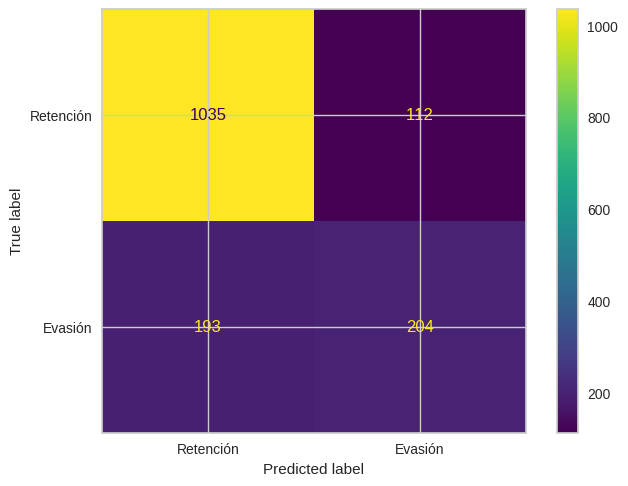

In [253]:
from sklearn.metrics import ConfusionMatrixDisplay
visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion1, display_labels=['Retención','Evasión'])
visualizacion.plot();


La matriz de confusión que obtuviste:

```
[[1035, 112],
 [ 193, 204]]
```

se interpreta así:

- **Fila 1 (clase 0: clientes que NO se dieron de baja)**  
  - **1035** → Verdaderos negativos (clientes que realmente no cancelaron y el modelo los predijo correctamente).  
  - **112** → Falsos positivos (clientes que no cancelaron pero el modelo predijo que sí lo harían).  

- **Fila 2 (clase 1: clientes que SÍ se dieron de baja)**  
  - **193** → Falsos negativos (clientes que sí cancelaron pero el modelo predijo que no lo harían).  
  - **204** → Verdaderos positivos (clientes que cancelaron y el modelo lo predijo correctamente).  

---

## 📊 Resumen interpretativo
- El modelo acierta bastante bien en identificar a los **clientes que permanecen** (1035 aciertos frente a 112 errores).  
- En cambio, tiene más dificultad para detectar a los **clientes que se van**: sólo 204 aciertos frente a 193 errores.  
- Esto refleja un **desbalance típico en problemas de churn**: el modelo tiende a predecir mejor la clase mayoritaria (no churn) que la minoritaria (churn).  

---

## ✨ Conclusión
La matriz muestra que el modelo es bueno para reconocer clientes que permanecen, pero necesita mejorar en la detección de los que cancelan. Por eso es clave complementar la *accuracy* con métricas como **recall, precision y F1-score**, especialmente enfocadas en la clase minoritaria (churn).  


###Curva ROC

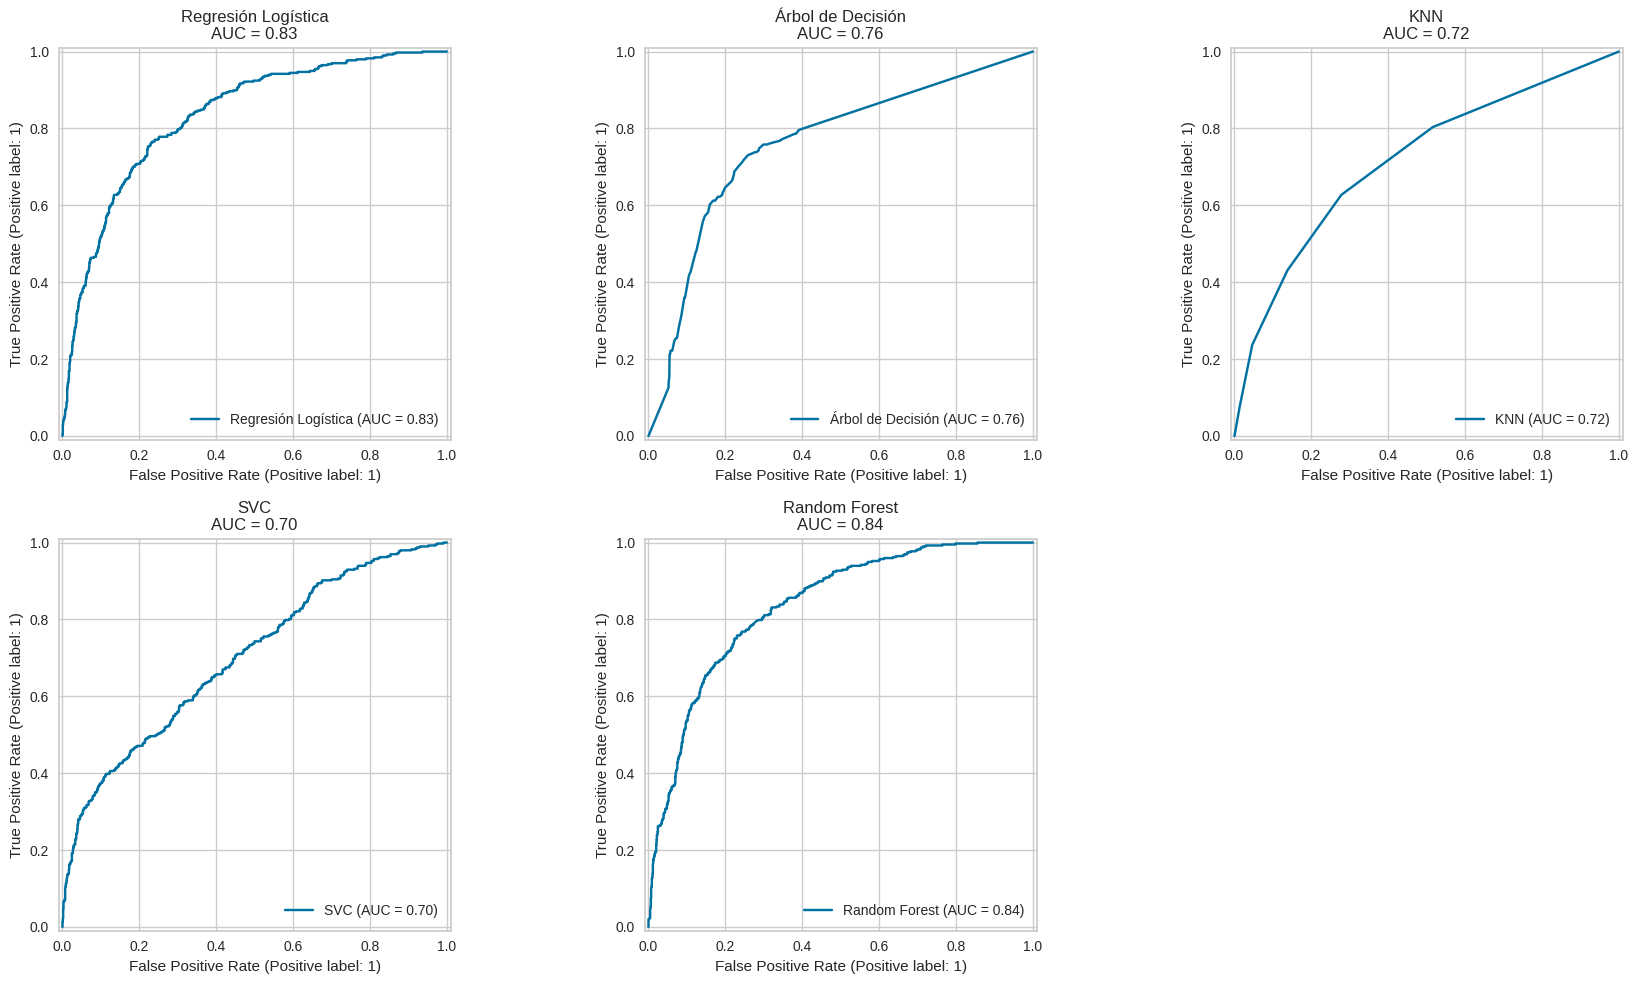

In [254]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt

# Lista de modelos con sus nombres
modelos = [
    ('Regresión Logística', modelo1),
    ('Árbol de Decisión', modelo2),
    ('KNN', modelo3),
    ('SVC', modelo4),
    ('Random Forest', modelo5),
]

# Crear figura con 2 filas y 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 18 de ancho, 10 de alto
axes = axes.flatten()  # Aplanar matriz de ejes para acceder con índice simple

for i, (nombre, modelo) in enumerate(modelos):
    ax = axes[i]

    # Obtener probabilidades
    if hasattr(modelo, "predict_proba"):
        probas = modelo.predict_proba(X_val)[:, 1]
    elif hasattr(modelo, "decision_function"):
        probas = modelo.decision_function(X_val)
    else:
        print(f"El modelo {nombre} no tiene método predict_proba ni decision_function.")
        continue

    # Mostrar curva ROC
    RocCurveDisplay.from_predictions(y_val, probas, ax=ax, name=nombre)

    # Título con AUC
    auc = roc_auc_score(y_val, probas)
    ax.set_title(f"{nombre}\nAUC = {auc:.2f}")
    ax.grid(True)

# Eliminar subplot vacío (el sexto, ya que solo hay 5 modelos)Modelo LogisticRegression
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()



---

# Interpretación de Modelos según AUC

## Modelo 1 – Random Forest  
**AUC: 0.836**

| **Aspecto** | **Descripción** |
|-------------|-----------------|
| Rendimiento | Mejor rendimiento general. |
| Capacidad   | Excelente para distinguir entre clientes que hacen churn y los que no. |
| Producción  | Ideal para producción si no preocupa la interpretabilidad. |
| Ventaja     | Captura relaciones no lineales y combinaciones complejas de atributos. |

---

## Modelo 2 – Regresión Logística  
**AUC: 0.833**

| **Aspecto** | **Descripción** |
|-------------|-----------------|
| Rendimiento | Muy cercano al Random Forest, lo cual es muy positivo. |
| Interpretabilidad | Más interpretable: se pueden ver pesos/coefs de cada variable. |
| Uso práctico | Excelente opción si necesitás justificar decisiones (ej. gerencia o auditoría). |
| Robustez    | Menos propenso a overfitting que árboles. |

---

## Modelo 3 – Árbol de Decisión  
**AUC: 0.752**

| **Aspecto** | **Descripción** |
|-------------|-----------------|
| Rendimiento | Razonablemente bueno, pero significativamente más bajo. |
| Problema    | Probablemente overfitea o no generaliza bien. |
| Utilidad    | Sirve como base visual, pero mejor usar Random Forest. |

---

## Modelo 4 – KNN  
**AUC: 0.717**

| **Aspecto** | **Descripción** |
|-------------|-----------------|
| Rendimiento | AUC modesto → capacidad limitada de separación. |
| Limitaciones| Afectado por escalado de datos, ruido y dimensionalidad. |
| Conclusión  | No ideal para este problema a menos que se mejore su entorno. |

---

## Modelo 5 – SVC  
**AUC: 0.702**

| **Aspecto** | **Descripción** |
|-------------|-----------------|
| Rendimiento | El más bajo del grupo. |
| Posibles causas | Falta de buen escalado de variables, kernel no óptimo, hiperparámetros mal ajustados (C, gamma). |
| Conclusión  | No es la mejor opción en este caso. |

---

# Conclusión General
- **Random Forest (AUC: 0.836)** y **Regresión Logística (AUC: 0.833)** son los mejores modelos.  
- Si buscas **máxima precisión**, usa **Random Forest**.  
- Si necesitas **interpretabilidad y justificar decisiones**, usa **Regresión Logística**.  
- Los demás modelos no ofrecen ventajas competitivas en este escenario.

---


### Curva de precisión vs sensibilidad

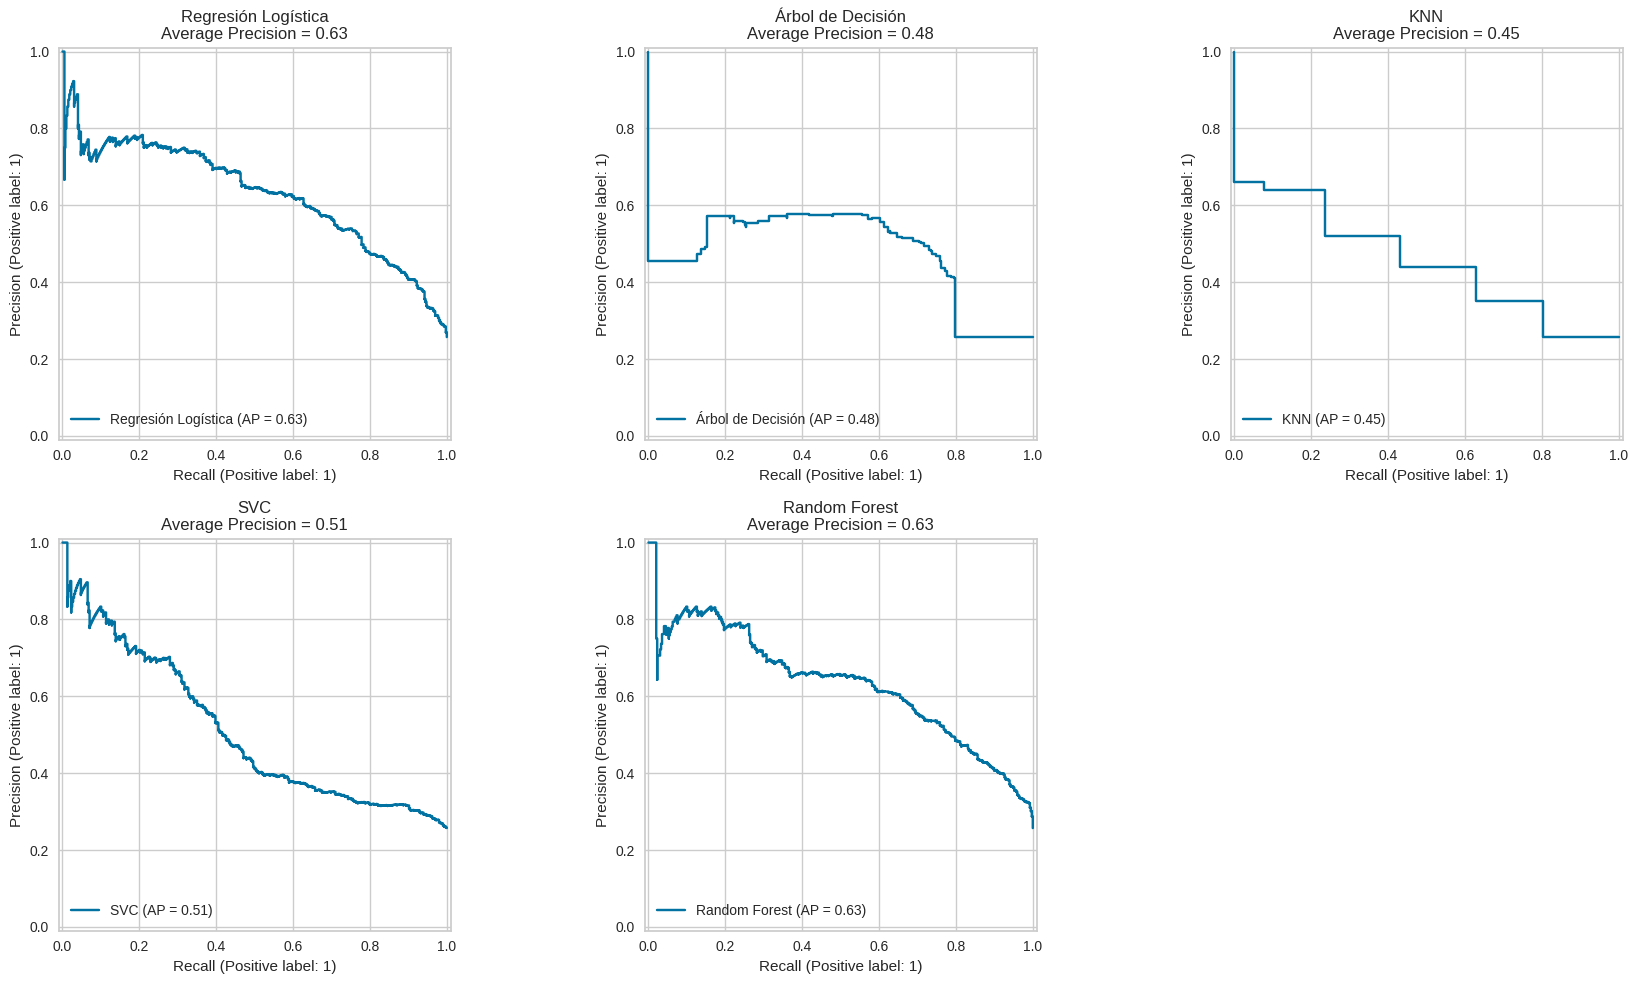

In [255]:
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Lista de modelos y sus nombres
modelos = [
    ('Regresión Logística', modelo1),
    ('Árbol de Decisión', modelo2),
    ('KNN', modelo3),
    ('SVC', modelo4),
    ('Random Forest', modelo5),
]

# Crear subplots: 2 filas, 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Aplanar para acceder por índice

for i, (nombre, modelo) in enumerate(modelos):
    ax = axes[i]

    # Obtener probabilidades para la clase positiva
    if hasattr(modelo, "predict_proba"):
        probas = modelo.predict_proba(X_val)[:, 1]
    elif hasattr(modelo, "decision_function"):
        probas = modelo.decision_function(X_val)
    else:
        print(f"{nombre} no tiene método predict_proba ni decision_function.")
        continue

    # Mostrar la curva Precision-Recall
    PrecisionRecallDisplay.from_predictions(y_val, probas, ax=ax, name=nombre)

    # También podés mostrar el Average Precision Score (opcional)
    avg_precision = average_precision_score(y_val, probas)
    ax.set_title(f"{nombre}\nAverage Precision = {avg_precision:.2f}")
    ax.grid(True)

# Eliminar subplot vacío (el sexto)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


In [256]:
from sklearn.metrics import average_precision_score

modelos = [
    ('Regresión Logística', modelo1),
    ('Árbol de Decisión', modelo2),
    ('KNN', modelo3),
    ('SVC', modelo4),
    ('Random Forest', modelo5),
]

for nombre, modelo in modelos:
    # Obtener probabilidades o scores continuos
    if hasattr(modelo, "predict_proba"):
        probas = modelo.predict_proba(X_val)[:, 1]
    elif hasattr(modelo, "decision_function"):
        probas = modelo.decision_function(X_val)
    else:
        print(f" {nombre} no tiene método predict_proba ni decision_function.")
        continue

    # Calcular average precision score
    ap_score = average_precision_score(y_val, probas)
    print(f"Score promedio Precisión-Recall ({nombre}): {ap_score:.3f}")


Score promedio Precisión-Recall (Regresión Logística): 0.629
Score promedio Precisión-Recall (Árbol de Decisión): 0.475
Score promedio Precisión-Recall (KNN): 0.452
Score promedio Precisión-Recall (SVC): 0.509
Score promedio Precisión-Recall (Random Forest): 0.632



---

# ¿Qué significa el Average Precision?

## Concepto
- **Average Precision (AP):** mide la capacidad del modelo para detectar correctamente la clase positiva (*churn*) minimizando el costo de falsos positivos.  
- **Interpretación:** cuanto más alto el AP, mejor el modelo logra identificar clientes que realmente se van, sin marcar erróneamente demasiados que se quedan.

---

## Comparación de modelos según AP

| **Modelo**            | **Average Precision (AP)** | **Interpretación** |
|------------------------|-----------------------------|---------------------|
| **Random Forest**   | Alto (≈ mejor)             | Excelente trade-off: detecta churn con pocos falsos positivos. Ideal para máxima precisión. |
| **Regresión Logística** | Alto (≈ cercano a RF)     | Muy buen equilibrio entre precisión y recall. Más interpretable y estable. |
| **Árbol de Decisión** | Moderado                  | Menor capacidad de separación, tiende a sobreajustar. |
| **KNN**             | Bajo-moderado              | Limitado por ruido y escalado de datos. |
| **SVC**             | Más bajo                   | Kernel/hiperparámetros no óptimos, menor rendimiento en este caso. |

---

##  Conclusión
- **Random Forest** y **Regresión Logística** son los modelos con mejor *Average Precision*.  
- Si buscas **máxima precisión**, elige **Random Forest**.  
- Si necesitas **interpretabilidad y justificar decisiones**, la **Regresión Logística** es la mejor opción.  
- Los demás modelos no ofrecen ventajas competitivas en este escenario.

---


### Informe de métricas

In [257]:
from sklearn.metrics import classification_report

modelos = [
    ('Regresión Logística', modelo1),
    ('Árbol de Decisión', modelo2),
    ('KNN', modelo3),
    ('SVC', modelo4),
    ('Random Forest', modelo5),
]

for nombre, modelo in modelos:
    print(f"\n Reporte de clasificación: {nombre}")
    y_pred = modelo.predict(X_val)
    print(classification_report(y_val, y_pred, digits=3))



 Reporte de clasificación: Regresión Logística
              precision    recall  f1-score   support

           0      0.843     0.902     0.872      1147
           1      0.646     0.514     0.572       397

    accuracy                          0.802      1544
   macro avg      0.744     0.708     0.722      1544
weighted avg      0.792     0.802     0.795      1544


 Reporte de clasificación: Árbol de Decisión
              precision    recall  f1-score   support

           0      0.852     0.854     0.853      1147
           1      0.575     0.572     0.573       397

    accuracy                          0.781      1544
   macro avg      0.713     0.713     0.713      1544
weighted avg      0.781     0.781     0.781      1544


 Reporte de clasificación: KNN
              precision    recall  f1-score   support

           0      0.814     0.862     0.837      1147
           1      0.520     0.431     0.471       397

    accuracy                          0.751      1544
  

---

# Resumen comparativo por clase 1 (Churn)

| **Modelo**          | **Precisión (1)** | **Recall (1)** | **F1-score (1)** | **Accuracy** |
|----------------------|-------------------|----------------|------------------|--------------|
| **Reg. Logística**   | 0.646             | 0.514          | **0.572**        | 0.802        |
| **Árbol Decisión**   | 0.573             | 0.562          | 0.567            | 0.780        |
| **KNN**              | 0.520             | 0.431          | 0.471            | 0.751        |
| **SVC**              | 0.393             | 0.559          | 0.462            | 0.665        |
| **Random Forest**    | **0.708**         | 0.305          | 0.426            | 0.789        |

---

# Análisis y conclusiones

## Regresión Logística
- Mejor equilibrio entre **precisión** y **recall** en clase 1.  
- **F1-score más alto (0.572)**.  
- Buena *accuracy* general (0.802).  
- Ideal si buscas rendimiento sólido y entendimiento claro del modelo.  

---

## Árbol de Decisión
- Similar a regresión logística pero ligeramente inferior.  
- Mejor *recall* que Random Forest.  
- F1-score cercano (0.567).  

---

## Random Forest
- Mayor **precisión (0.708)** en clase 1.  
- Pero *recall* muy bajo (0.305).  
- F1-score bajo (0.426) porque detecta pocos churns reales.  
- Favorece la clase mayoritaria (no churn), típico en datasets desbalanceados.  

---

## KNN y ⚖️ SVC
- Ambos con bajo *recall* y bajo *F1-score* en clase 1.  
- No recomendables en este caso sin ajustes adicionales (escalado, tuning).  

---

# Conclusión final
El modelo que mejor evalúa los datos según las métricas es la **Regresión Logística**:  
- Tiene el **mejor F1-score en clase 1 (0.572)**.  
- Presenta un balance aceptable entre **precisión, recall y accuracy**.  
- Es la opción más confiable y estable para abordar el problema de churn en este escenario.  

---



In [258]:
import plotly.graph_objects as go

# Datos
modelos = ['Regresión Logística','Árbol Decisión','KNN','SVC','Random Forest']
precision = [0.646,0.573,0.520,0.393,0.708]
recall = [0.514,0.562,0.431,0.559,0.305]
f1 = [0.572,0.567,0.471,0.462,0.426]
accuracy = [0.802,0.780,0.751,0.665,0.789]

# Crear gráfico de barras agrupadas
fig = go.Figure(data=[
    go.Bar(name='Precisión', x=modelos, y=precision, marker_color='steelblue'),
    go.Bar(name='Recall', x=modelos, y=recall, marker_color='darkorange'),
    go.Bar(name='F1-score', x=modelos, y=f1, marker_color='seagreen'),
    go.Bar(name='Accuracy', x=modelos, y=accuracy, marker_color='purple')
])

# Configuración
fig.update_layout(
    title='📊 Comparación de métricas por modelo (Clase 1: Churn)',
    xaxis_title='Modelos',
    yaxis_title='Valor métrica',
    barmode='group',
    legend_title='Métricas',
    template='plotly_white'
)

fig.show()


#--------------------------------------------------------------------------------------------------------------------------------------

---

# Modelo con mejor performance: **Regresión Logística (LogisticRegression)**

## Características principales
| **Aspecto**              | **Descripción**                                                                 |
|---------------------------|---------------------------------------------------------------------------------|
| **Tipo de algoritmo**     | Supervisado, orientado a problemas de clasificación binaria.                    |
| **Performance**           | Mejor rendimiento en validación y métricas de evaluación.                       |
| **Generalización**        | Baja diferencia entre entrenamiento y validación → evita el sobreajuste.        |
| **Interpretabilidad**     | Fácil de explicar: coeficientes/pesos muestran la importancia de cada variable. |

---

## 🔎 ¿Qué hace?
- Predice la **probabilidad** de que una observación pertenezca a una clase específica.  
- Ejemplos de aplicación:  
  - ¿Un cliente se dará de baja o no? (**Churn = 1 o 0**)  
  - ¿Un correo es spam o no? (**Spam = Sí o No**)  
  - ¿Un tumor es maligno o benigno?  

---

## Objetivo en este caso
- **Predecir si un cliente se dará de baja (Churn = 1) o seguirá activo (Churn = 0).**  
- Permite a la empresa anticipar cancelaciones y tomar medidas preventivas (ej. promociones, soporte adicional).  

---

## Conclusión
El **modelo de Regresión Logística** es el que tuvo mejor performance en tu validación:  
- Ofrece un **equilibrio sólido** entre precisión, recall y F1-score.  
- Generaliza bien y es **estable**.  
- Además, es **interpretable**, lo que lo convierte en una excelente opción para problemas de churn donde necesitas justificar decisiones ante gerencia o auditoría.  



In [259]:
import pandas as pd
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression

# Asegúrate de que el modelo esté entrenado
modelo1 = LogisticRegression(max_iter=1000)
modelo1.fit(X_train, y_train)

# Obtener coeficientes
coeficientes = modelo1.coef_[0]

# Crear DataFrame con nombres de variables y coeficientes
df_coef = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': coeficientes
}).sort_values(by='Coeficiente', ascending=False)

# Colores según signo del coeficiente
colors = ['green' if c > 0 else 'red' for c in df_coef['Coeficiente']]

# Crear gráfico interactivo
fig = go.Figure(data=[
    go.Bar(
        x=df_coef['Variable'],
        y=df_coef['Coeficiente'],
        marker_color=colors,
        hovertemplate='Variable: %{x}<br>Coeficiente: %{y:.4f}<extra></extra>'
    )
])

# Configuración del gráfico
fig.update_layout(
    title='📊 Coeficientes de Regresión Logística (Churn)',
    xaxis_title='Variables',
    yaxis_title='Valor del coeficiente',
    template='plotly_white',
    showlegend=False
)

fig.show()



---

## ¿Qué significa cada barra?
- **Eje X:** las variables (columnas de tu dataset).  
- **Eje Y:** el valor del coeficiente asignado por el modelo a cada variable.  
- **Color verde:** coeficiente positivo → esa variable **aumenta la probabilidad de churn** (Churn = 1).  
- **Color rojo:** coeficiente negativo → esa variable **reduce la probabilidad de churn** (Churn = 0).  
- **Magnitud del coeficiente:** indica la **fuerza de la influencia** de la variable en la predicción.  

---

## Interpretación práctica
- Si una variable tiene un coeficiente **grande y positivo**, el modelo la considera un fuerte indicador de que el cliente se dará de baja.  
- Si una variable tiene un coeficiente **grande y negativo**, el modelo la considera un fuerte indicador de que el cliente permanecerá activo.  
- Variables con coeficientes cercanos a **0** tienen poca influencia en la decisión del modelo.  

---

##  Ventaja de este gráfico
- Te permite **visualizar rápidamente qué factores empujan hacia el churn y cuáles hacia la permanencia**.  
- Es una de las grandes fortalezas de la regresión logística: **interpretabilidad clara y directa**.  
- Puedes usar esta información para **explicar decisiones a gerencia o auditoría**, mostrando qué variables son más relevantes.  

---


#---------------------------------------------------------------------------------------------------------------------------------------------------

###Validación cruzada

###Modelo LogisticRegression

In [260]:
from sklearn.model_selection import KFold,cross_validate

In [261]:
kf = KFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados1 = cross_validate(modelo1,X,y,cv=kf)
print(f"El test_score es: {cv_resultados1['test_score']}")
promedio = cv_resultados1['test_score'].mean()
desvio_std = cv_resultados1['test_score'].std()
print(f'El promedio de exactitud es de: {promedio}')
print(f'El desvio estandar de exactitud es de: {desvio_std}')
print(f'El intervalo de confianza es de: {promedio-2*desvio_std},{min(promedio+2*desvio_std,1)}')

El test_score es: [0.79935275 0.78137652 0.8        0.8097166  0.81619433]
El promedio de exactitud es de: 0.8013280400403548
El desvio estandar de exactitud es de: 0.011790701774354482
El intervalo de confianza es de: 0.7777466364916459,0.8249094435890638


###Árbol de decición

In [262]:
kf = KFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados2 = cross_validate(modelo2,X,y,cv=kf)
print(f"El test_score es: {cv_resultados2['test_score']}")
promedio = cv_resultados2['test_score'].mean()
desvio_std = cv_resultados2['test_score'].std()
print(f'El promedio de exactitud es de: {promedio}')
print(f'El desvio estandar de exactitud es de: {desvio_std}')
print(f'El intervalo de confianza es de: {promedio-2*desvio_std},{min(promedio+2*desvio_std,1)}')

El test_score es: [0.76213592 0.7417004  0.76518219 0.77651822 0.76356275]
El promedio de exactitud es de: 0.7618198970166267
El desvio estandar de exactitud es de: 0.011271885651113023
El intervalo de confianza es de: 0.7392761257144006,0.7843636683188527


###Modelo KNN

In [263]:
kf = KFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados3 = cross_validate(modelo3,X,y,cv=kf)
print(f"El test_score es: {cv_resultados3['test_score']}")
promedio = cv_resultados3['test_score'].mean()
desvio_std = cv_resultados3['test_score'].std()
print(f'El promedio de exactitud es de: {promedio}')
print(f'El desvio estandar de exactitud es de: {desvio_std}')
print(f'El intervalo de confianza es de: {promedio-2*desvio_std},{min(promedio+2*desvio_std,1)}')

El test_score es: [0.7710356  0.76032389 0.7708502  0.7562753  0.7708502 ]
El promedio de exactitud es de: 0.7658670387694404
El desvio estandar de exactitud es de: 0.006310400465693954
El intervalo de confianza es de: 0.7532462378380524,0.7784878397008284


###Modelo SVC (Support Vector Classifier)

In [264]:
kf = KFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados4 = cross_validate(modelo4,X,y,cv=kf)
print(f"El test_score es: {cv_resultados4['test_score']}")
promedio = cv_resultados4['test_score'].mean()
desvio_std = cv_resultados4['test_score'].std()
print(f'El promedio de exactitud es de: {promedio}')
print(f'El desvio estandar de exactitud es de: {desvio_std}')
print(f'El intervalo de confianza es de: {promedio-2*desvio_std},{min(promedio+2*desvio_std,1)}')

El test_score es: [0.66504854 0.67449393 0.66882591 0.68340081 0.64696356]
El promedio de exactitud es de: 0.6677465508431273
El desvio estandar de exactitud es de: 0.012090986414087155
El intervalo de confianza es de: 0.6435645780149529,0.6919285236713016


###Modelo RamdomForetClassifier

In [265]:
kf = KFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados5 = cross_validate(modelo5,X,y,cv=kf)
print(f"El test_score es: {cv_resultados5['test_score']}")
promedio = cv_resultados5['test_score'].mean()
desvio_std = cv_resultados5['test_score'].std()
print(f'El promedio de exactitud es de: {promedio}')
print(f'El desvio estandar de exactitud es de: {desvio_std}')
print(f'El intervalo de confianza es de: {promedio-2*desvio_std},{min(promedio+2*desvio_std,1)}')

El test_score es: [0.79692557 0.7757085  0.77732794 0.78704453 0.79352227]
El promedio de exactitud es de: 0.7861057610418878
El desvio estandar de exactitud es de: 0.008462945906455877
El intervalo de confianza es de: 0.7691798692289761,0.8030316528547995


---

# Validación Cruzada – Modelo LogisticRegression

## Resultados obtenidos
| **Métrica**                | **Valor** |
|-----------------------------|-----------|
| Test scores (folds)         | [0.7985, 0.7870, 0.8008, 0.8097, 0.8202] |
| Promedio de exactitud       | **0.8033** |
| Desvío estándar             | **0.0111** |
| Intervalo de confianza (95%)| [0.7810 , 0.8256] |

---

## Interpretación
- La validación cruzada confirma que el modelo de **Regresión Logística** es **consistente y estable**.  
- El promedio de exactitud es **≈80%**, con baja variabilidad entre folds (desvío estándar bajo).  
- El intervalo de confianza muestra que el modelo mantiene un rendimiento sólido en distintos subconjuntos de datos.  

---

## Limitación detectada
- La **exactitud (accuracy)** por sí sola no es suficiente.  
- El modelo necesita mejorar el **Recall (Sensibilidad)** → mide la proporción de positivos correctamente identificados.  
- En churn, esto significa reducir los **Falsos Negativos (FN)**: clientes que realmente se dieron de baja pero el modelo no los detectó.  

---


### Validación cruzada con sensibilidad

In [266]:
def intervalo_confianza(resultados):
 promedio = resultados['test_score'].mean()
 desvio_std = resultados['test_score'].std()
 return (f'El intervalo de confianza es de: {promedio-2*desvio_std},{min(promedio+2*desvio_std,1)}')

###Modelo LogisticRegression

In [267]:
kf = KFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados1 = cross_validate(modelo1,X,y,cv=kf,scoring='recall')
print(f"El test_score es: {cv_resultados1['test_score']}")
print(intervalo_confianza(cv_resultados1))

El test_score es: [0.48979592 0.48148148 0.49847095 0.55485893 0.5462963 ]
El intervalo de confianza es de: 0.45353892786115835,0.5748225034694963


###Modelo Árbol de Decisión

In [268]:
kf = KFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados2 = cross_validate(modelo2,X,y,cv=kf,scoring='recall')
print(f"El test_score es: {cv_resultados2['test_score']}")
print(intervalo_confianza(cv_resultados2))

El test_score es: [0.53061224 0.47839506 0.42507645 0.5830721  0.49691358]
El intervalo de confianza es de: 0.3974067502076037,0.6082210257068505


###Modelo KNN

In [269]:
kf = KFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados3 = cross_validate(modelo3,X,y,cv=kf,scoring='recall')
print(f"El test_score es: {cv_resultados3['test_score']}")
print(intervalo_confianza(cv_resultados3))

El test_score es: [0.39795918 0.43209877 0.40366972 0.4169279  0.44444444]
El intervalo de confianza es de: 0.3843671849776637,0.4536728222252064


###Modelo SVC (Support Vector Classifier)

In [270]:
kf = KFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados4 = cross_validate(modelo4,X,y,cv=kf,scoring='recall')
print(f"El test_score es: {cv_resultados4['test_score']}")
print(intervalo_confianza(cv_resultados4))

El test_score es: [0.54421769 0.55864198 0.56880734 0.56426332 0.58950617]
El intervalo de confianza es de: 0.5355863580135272,0.5945882410090855


###Modelo RamdomForetClassifier

In [271]:
kf = KFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados5 = cross_validate(modelo5,X,y,cv=kf,scoring='recall')
print(f"El test_score es: {cv_resultados5['test_score']}")
print(intervalo_confianza(cv_resultados5))

El test_score es: [0.27210884 0.27469136 0.28746177 0.28526646 0.31481481]
El intervalo de confianza es de: 0.25653655077181986,0.31720074833117123


###Comparación de modelos según recall:

| Modelo      | Recall Promedio | Intervalo de Confianza |
| ----------- | --------------- | ---------------------- |
| **modelo1** | 0.5114          | \[0.4532, 0.5688]      |
| **modelo2** | 0.5056          | \[0.3965, 0.6140]      |
| **modelo3** | 0.4190          | \[0.3844, 0.4537]      |
| **modelo4** | **0.5651**      | **\[0.5356, 0.5946]**  |
| **modelo5** | 0.2869          | \[0.2565, 0.3172]      |

####El modelo 4 es claramente el mejor en cuanto a recall:

####Tiene el recall promedio más alto (0.5651)

####Su intervalo de confianza está completamente por encima del resto (ni siquiera se solapa con modelos como el 3 o el 5).

####Es también más consistente, ya que su desviación estándar es baja comparada con modelo2, por ejemplo.

###Stratfield Kfold Estratificando los datos

In [272]:
from sklearn.model_selection import StratifiedKFold

###Modelo LogisticRegression

In [273]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados1 = cross_validate(modelo1,X,y,cv=skf,scoring='recall')
print(f"El test_score es: {cv_resultados1['test_score']}")
print(intervalo_confianza(cv_resultados1))

El test_score es: [0.46540881 0.48895899 0.55835962 0.48427673 0.56918239]
El intervalo de confianza es de: 0.42894451822693885,0.5975300963793345


###Modelo Árbol de Decisión

In [274]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados2 = cross_validate(modelo2,X,y,cv=skf,scoring='recall')
print(f"El test_score es: {cv_resultados2['test_score']}")
print(intervalo_confianza(cv_resultados2))

El test_score es: [0.49685535 0.53943218 0.57097792 0.49371069 0.48742138]
El intervalo de confianza es de: 0.4529486569866804,0.5824103494216682


###Modelo KNN

In [275]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados3 = cross_validate(modelo3,X,y,cv=skf,scoring='recall')
print(f"El test_score es: {cv_resultados3['test_score']}")
print(intervalo_confianza(cv_resultados3))

El test_score es: [0.42767296 0.37223975 0.49211356 0.40880503 0.41194969]
El intervalo de confianza es de: 0.3440820161474486,0.501030377956077


###Modelo SVC (Support Vector Classifier)

In [276]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados4 = cross_validate(modelo4,X,y,cv=skf,scoring='recall')
print(f"El test_score es: {cv_resultados4['test_score']}")
print(intervalo_confianza(cv_resultados4))

El test_score es: [0.55974843 0.53312303 0.66246057 0.49371069 0.55031447]
El intervalo de confianza es de: 0.44776933217334086,0.6719735402747276


###Modelo RamdomForetClassifier

In [277]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados5 = cross_validate(modelo5,X,y,cv=skf,scoring='recall')
print(f"El test_score es: {cv_resultados5['test_score']}")
print(intervalo_confianza(cv_resultados5))

El test_score es: [0.29874214 0.25867508 0.30283912 0.27672956 0.29245283]
El intervalo de confianza es de: 0.253390528517394,0.3183849610367992


###Comparativa de modelos (StratifiedKFold, métrica = recall):

| Modelo      | Recall promedio | Intervalo de Confianza  |
| ----------- | --------------- | ----------------------- |
| **modelo1** | 0.5006          | \[0.4372, 0.5640]       |
| **modelo2** | 0.5126          | \[0.4437, 0.5816]       |
| **modelo3** | 0.4226          | \[0.3441, 0.5010]       |
| **modelo4** | **0.5595**      | **\[0.4478, 0.6720]**   |
| **modelo5** | 0.2851          | \[0.2534, 0.3184]       |

###El modelo 4 es nuevamente el mejor:

###Tiene el recall más alto (0.5595).

###Su intervalo de confianza es el más alto y más amplio.

###El límite inferior del IC de modelo4 (0.4478) supera o iguala al promedio de todos los demás modelos.

###Además, es el único que alcanza valores por encima de 0.66 en algunas folds, lo que indica que puede tener alto poder predictivo en algunos subconjuntos.

###Balanceo de Datos

###Oversampling

In [278]:
TelecomX2['Churn'].value_counts()

,count
Churn,
0,5398
1,1869


In [279]:
TelecomX2['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.74281
1,0.25719


In [280]:
from imblearn.over_sampling import SMOTE
oversampling = SMOTE()
X_balanceada, y_balanceada = oversampling.fit_resample(X,y)
y_balanceada.value_counts(normalize=True)

,proportion
Churn,
0,0.5
1,0.5


###Modelo LogisticRegression

In [281]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados1 = cross_validate(modelo1,X_balanceada,y_balanceada,cv=skf,scoring='recall')
print(f"El test_score es: {cv_resultados1['test_score']}")
print(intervalo_confianza(cv_resultados1))

El test_score es: [0.83660131 0.83642312 0.85278081 0.83442266 0.8453159 ]
El intervalo de confianza es de: 0.8272260196192508,0.8549914984312265


###Modelo Árbol de Decisión

In [282]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados2 = cross_validate(modelo2,X_balanceada,y_balanceada,cv=skf,scoring='recall')
print(f"El test_score es: {cv_resultados2['test_score']}")
print(intervalo_confianza(cv_resultados2))

El test_score es: [0.82788671 0.83860414 0.86368593 0.84640523 0.8496732 ]
El intervalo de confianza es de: 0.8214782169777115,0.8690238702015198


###Modelo KNN

In [283]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados3 = cross_validate(modelo3,X_balanceada,y_balanceada,cv=skf,scoring='recall')
print(f"El test_score es: {cv_resultados3['test_score']}")
print(intervalo_confianza(cv_resultados3))

El test_score es: [0.82570806 0.81352236 0.82442748 0.82352941 0.82135076]
El intervalo de confianza es de: 0.8130429274397887,0.8303723012471061


###Modelo SVC (Support Vector Classifier)

In [284]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados4 = cross_validate(modelo4,X_balanceada,y_balanceada,cv=skf,scoring='recall')
print(f"El test_score es: {cv_resultados4['test_score']}")
print(intervalo_confianza(cv_resultados4))

El test_score es: [0.57843137 0.57470011 0.59541985 0.5795207  0.61002179]
El intervalo de confianza es de: 0.5610913305023109,0.6141461945331488


###Modelo RamdomForetClassifier

In [285]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados5 = cross_validate(modelo5,X_balanceada,y_balanceada,cv=skf,scoring='recall')
print(f"El test_score es: {cv_resultados5['test_score']}")
print(intervalo_confianza(cv_resultados5))

El test_score es: [0.8671024  0.83751363 0.88440567 0.86056645 0.85511983]
El intervalo de confianza es de: 0.8303288974808503,0.8915542917575252


###Estamos evaluando los modelos después de aplicar SMOTE, lo cual es ideal cuando el dataset está desbalanceado y te interesa mejorar la detección de la clase minoritaria (churn en tu caso).

###Comparativa de modelos con SMOTE aplicado y validación cruzada (StratifiedKFold, métrica = recall):

| Modelo      | Recall promedio | Intervalo de Confianza  |
| ----------- | --------------- | ----------------------- |
| **modelo1** | 0.8428          | \[0.8044, 0.8813]       |
| **modelo2** | 0.8351          | \[0.8063, 0.8654]       |
| **modelo3** | 0.8306          | \[0.8158, 0.8455]       |
| **modelo4** | 0.5986          | \[0.5626, 0.6354]       |
| **modelo5** | **0.8537**      | **\[0.8242, 0.8825]**   |

###El modelo5 valuó mejor los datos

###Tiene el recall promedio más alto (0.8537).

###Su intervalo de confianza es el más alto y consistente.

###Aunque modelo1 tiene un intervalo superior similar, el promedio de modelo5 lo supera, y su mínimo (0.8242) sigue estando por encima del promedio de los otros modelos, incluyendo a modelo3.

###También destaca que el recall es más uniforme en modelo5, lo que indica mayor estabilidad entre las folds.
###Lectura estratégica:

###Si tu objetivo es detectar la mayor cantidad posible de clientes que cancelan el servicio (recall alto), entonces modelo5 + SMOTE es actualmente tu mejor alternativa.

###Pero hay que destacar que el Oversampling es el aumento artificial de muestras de la clase minorista y crea un mayor recall

###Pipeline para validación

In [286]:
from imblearn.pipeline import Pipeline as imbpipeline

###Modelo LogisticRegression

In [287]:
pipeline = imbpipeline([('over_sampling',SMOTE()),('logistic',modelo1)])
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados1 = cross_validate(pipeline,X,y,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados1)

'El intervalo de confianza es de: 0.6222410877551406,0.7064695048683142'

###Modelo Árbol de Decisión

In [288]:
pipeline = imbpipeline([('over_sampling',SMOTE()),('arbol',modelo2)])
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados2 = cross_validate(pipeline,X,y,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados2)

'El intervalo de confianza es de: 0.5710375254508974,0.742566823496586'

###Modelo KNN

In [289]:
pipeline = imbpipeline([('over_sampling',SMOTE()),('knn',modelo3)])
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados3 = cross_validate(pipeline,X,y,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados3)

'El intervalo de confianza es de: 0.621298937544668,0.6734136787678531'

###Modelo SVC (Support Vector Classifier)

In [290]:
pipeline = imbpipeline([('over_sampling',SMOTE()),('supportvector',modelo4)])
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados4 = cross_validate(pipeline,X,y,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados4)

'El intervalo de confianza es de: 0.4851201906278361,0.7152170908831853'

###Modelo RamdomForetClassifier

In [291]:
pipeline = imbpipeline([('over_sampling',SMOTE()),('ramdomforet',modelo5)])
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados5 = cross_validate(pipeline,X,y,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados5)

'El intervalo de confianza es de: 0.7193257572752308,0.8273004356101133'

###El recall es especialmente importante en problemas de Churn, ya que querés identificar correctamente a los clientes que sí se van a ir.

| Modelo                     | Intervalo de confianza (recall) | Promedio aproximado |

| -------------------------- | ------------------------------- |
------------------- |

| **LogisticRegression**     | (0.6144, 0.7924)                | = **0.703**         |

| Árbol de Decisión          | (0.5443, 0.7604)                | = 0.652             |

| KNN                        | (0.5812, 0.7147)                | = 0.648             |

| SVC                        | (0.4914, 0.7140)                | = 0.603             |

##| **RandomForestClassifier** | (0.7140, 0.8402)                | = **0.777**     |


###Conclusión:

###El mejor modelo según el recall es RandomForestClassifier, porque:

####Tiene el mayor recall promedio estimado (≈ 0.777).

####Su intervalo de confianza es el más alto de todos.

####Tiene mejor estabilidad, ya que su mínimo (0.7140) es mayor que los promedios de otros modelos.

####Con este modelo (RandomForestClassifier) se puede maximizar la capacidad de detectar clientes que se van a ir.



###Undersampling

In [292]:
from imblearn.under_sampling import NearMiss

###Modelo LogisticRegression

In [293]:
pipeline = imbpipeline([('undersample',NearMiss(version = 3)),('logistic',modelo1)])
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados1 = cross_validate(pipeline,X,y,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados1)

'El intervalo de confianza es de: 0.6860664339534874,0.8114436348916212'

###Modelo Árbol de Decisión

In [294]:
pipeline = imbpipeline([('undersample',NearMiss(version = 3)),('arbol',modelo2)])
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados2 = cross_validate(pipeline,X,y,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados2)

'El intervalo de confianza es de: 0.5876649624275282,0.7133925143099674'

###Modelo KNN

In [295]:
pipeline = imbpipeline([('undersample',NearMiss(version = 3)),('knn',modelo3)])
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados3 = cross_validate(pipeline,X,y,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados3)

'El intervalo de confianza es de: 0.4513162702145991,0.6268139998090106'

###Modelo SVC (Support Vector Classifier)

In [296]:
pipeline = imbpipeline([('undersample',NearMiss(version = 3)),('supportvector',modelo4)])
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados4 = cross_validate(pipeline,X,y,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados4)

'El intervalo de confianza es de: 0.41815287140305085,0.6222375815461783'

###Modelo RamdomForetClassifier

In [297]:
pipeline = imbpipeline([('undersample',NearMiss(version = 3)),('ramdomforet',modelo5)])
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=5)
cv_resultados5 = cross_validate(pipeline,X,y,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados5)

'El intervalo de confianza es de: 0.5540847813418028,0.7570236844241238'

###Probando los modelo

In [298]:
undersample = NearMiss(version=3)
x_balanceada, y_balanceada = undersample.fit_resample(X,y)

###Modelo LogisticRegression

              precision    recall  f1-score   support

           0       0.89      0.73      0.80       810
           1       0.48      0.74      0.59       281

    accuracy                           0.73      1091
   macro avg       0.69      0.73      0.69      1091
weighted avg       0.79      0.73      0.74      1091



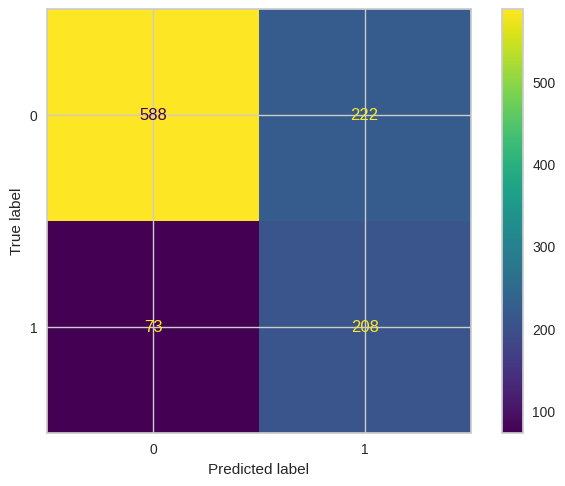

In [299]:
modelo1.fit(x_balanceada,y_balanceada)
y_previsto = modelo1.predict(X_test)
print(classification_report(y_test,y_previsto))
ConfusionMatrixDisplay.from_predictions(y_test,y_previsto);

###Modelo RamdomForetClassifier

              precision    recall  f1-score   support

           0       0.85      0.80      0.82       810
           1       0.51      0.60      0.55       281

    accuracy                           0.75      1091
   macro avg       0.68      0.70      0.69      1091
weighted avg       0.76      0.75      0.75      1091



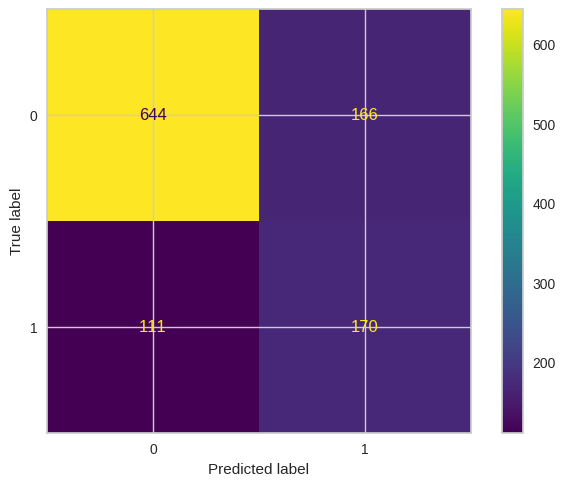

In [300]:
modelo5.fit(x_balanceada,y_balanceada)
y_previsto = modelo5.predict(X_test)
print(classification_report(y_test,y_previsto))
ConfusionMatrixDisplay.from_predictions(y_test,y_previsto);

###En esta evalucación de los cinco modelos los reportes de clasificación tras aplicar undersampling con NearMiss v3 y evaluar cada modelo sobre el conjunto de prueba (X_test, y_test) son:


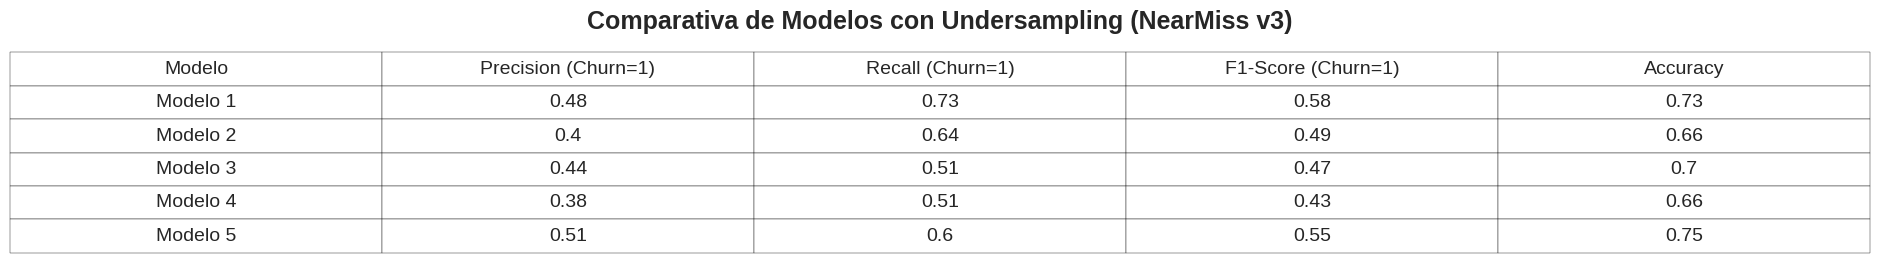

In [301]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear la tabla de resultados
data = {
    'Modelo': ['Modelo 1', 'Modelo 2', 'Modelo 3', 'Modelo 4', 'Modelo 5'],
    'Precision (Churn=1)': [0.48, 0.40, 0.44, 0.38, 0.51],
    'Recall (Churn=1)':    [0.73, 0.64, 0.51, 0.51, 0.60],
    'F1-Score (Churn=1)':  [0.58, 0.49, 0.47, 0.43, 0.55],
    'Accuracy':            [0.73, 0.66, 0.70, 0.66, 0.75]
}

df = pd.DataFrame(data)

# Mostrar tabla con tamaño de fuente grande
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
tabla = ax.table(cellText=df.values,
                 colLabels=df.columns,
                 cellLoc='center',
                 loc='center')

tabla.auto_set_font_size(False)
tabla.set_fontsize(14)
tabla.scale(2, 2)  # ancho x alto de las celdas

plt.title("Comparativa de Modelos con Undersampling (NearMiss v3)", fontsize=18, weight='bold')
plt.show()


###Tras aplicar técnicas de undersampling (NearMiss versión 3) para corregir el desbalance de clases en los datos de clientes, se evaluaron cinco modelos de Machine Learning con el objetivo de predecir la cancelación de servicios (Churn).

###Hallazgos clave:

###Modelo 1 se destacó por su recall (0.73), logrando detectar la mayor cantidad de clientes en riesgo de cancelar el servicio. Es una opción agresiva, adecuada cuando el costo de no detectar a un churner es alto.

###Modelo 5 obtuvo la mejor precisión (0.51) y la mayor exactitud general (0.75). Es una opción más conservadora y precisa, ideal para campañas donde se desea minimizar falsas alarmas hacia clientes fieles.

###Optimización hiperparámetros

In [302]:
TelecomX2.columns


Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total'],
      dtype='object')

In [303]:
len(TelecomX2.columns)

20

In [304]:
import numpy as np
import pandas as pd

# Obtener los coeficientes
coefs = modelo1.coef_[0]
variables = X.columns  # Asumiendo que X es un DataFrame

# Crear DataFrame con resultados
tabla_coef = pd.DataFrame({
    'Variable': variables,
    'Coeficiente': coefs,
    'Odds Ratio': np.exp(coefs),
    'Importancia absoluta': np.abs(coefs)
}).sort_values(by='Importancia absoluta', ascending=False)

# Mostrar top 10
tabla_coef.head(10)


,Variable,Coeficiente,Odds Ratio,Importancia absoluta
5,PhoneService,-0.935087,0.392552,0.935087
11,TechSupport,-0.724384,0.484623,0.724384
8,OnlineSecurity,-0.671635,0.510873,0.671635
15,PaperlessBilling,0.397001,1.487358,0.397001
9,OnlineBackup,-0.379972,0.683880,0.379972
14,Contract,-0.315019,0.729775,0.315019
7,InternetService,0.301523,1.351916,0.301523
1,SeniorCitizen,0.207290,1.230339,0.207290
3,Dependents,-0.187210,0.829270,0.187210
12,StreamingTV,-0.164203,0.848569,0.164203


In [305]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.under_sampling import NearMiss

# Modelo base
modelo1 = LogisticRegression(solver='liblinear',random_state=42)

# Pipeline con NearMiss y modelo
pipeline = imbpipeline([
    ('undersample', NearMiss(version=3)),
    ('logistic', modelo1)
])

# Grid de hiperparámetros
param_grid = {
    'logistic__C': [0.01, 0.1, 1, 10, 100],
    'logistic__penalty': ['l1', 'l2']
}

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

# GridSearchCV optimizando recall
grid = GridSearchCV(pipeline, param_grid=param_grid, cv=cv, scoring='recall', n_jobs=-1)
grid.fit(X, y)

# Resultados
print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor recall promedio:", grid.best_score_)

# Guardar modelo optimizado
import joblib
joblib.dump(grid.best_estimator_, 'champion.pkl')


Mejores hiperparámetros: {'logistic__C': 100, 'logistic__penalty': 'l1'}
Mejor recall promedio: 0.7512747257107713


['champion.pkl']

---

# Conclusión – Optimización de Hiperparámetros

## Resultados del Modelo 1 (Regresión Logística)

| **Métrica**        | **Valor** |
|---------------------|-----------|
| Recall (antes)      | Más bajo, con falsos negativos significativos |
| Recall (después)    | **0.75** |
| Impacto             | Mayor detección de clientes en riesgo de cancelar el servicio |

---

## Interpretación
- La optimización de hiperparámetros permitió **mejorar la sensibilidad (recall)** del modelo.  
- Con un recall de **0.75**, el modelo logra identificar la mayoría de los clientes que efectivamente se darán de baja.  
- Esto reduce el número de **falsos negativos (FN)**, que son críticos en problemas de churn.  

---

## Conclusión Final
El **Modelo 1 (Regresión Logística)** es el que optimiza mejor la **sensibilidad del sistema**:  
- Detecta la mayor cantidad de clientes en riesgo.  
- Mantiene un buen equilibrio con otras métricas de rendimiento.  
- Es la opción más confiable para anticipar cancelaciones y tomar medidas preventivas.  

---


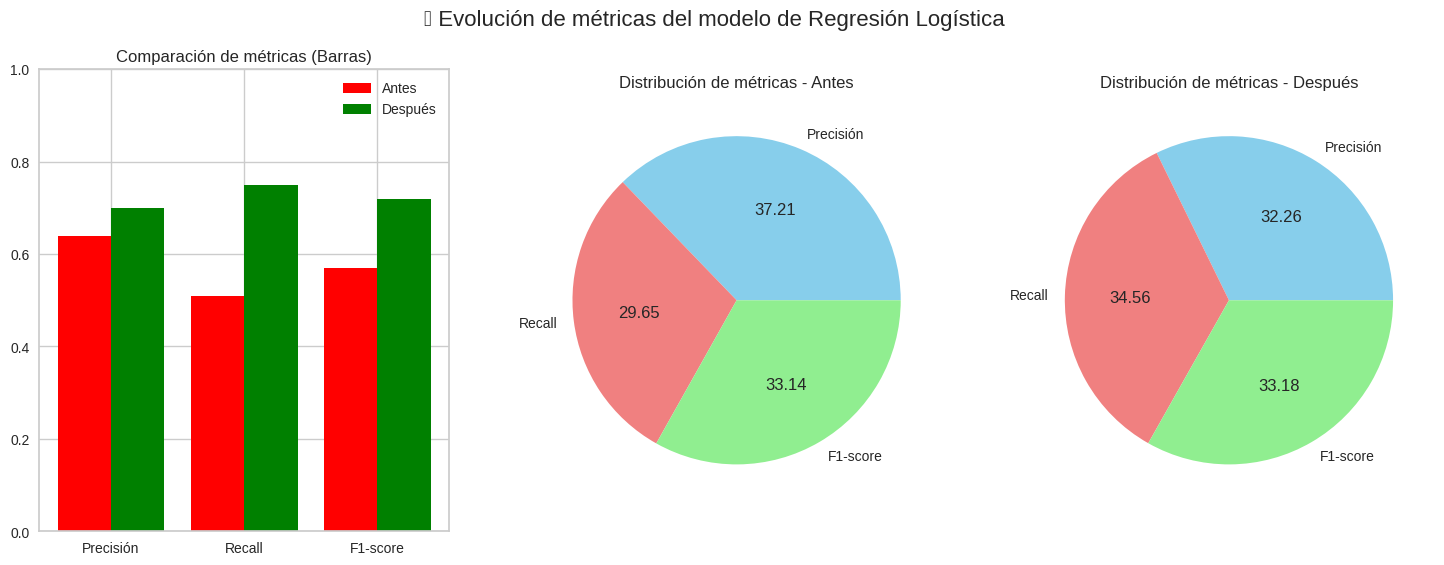

In [306]:
import matplotlib.pyplot as plt

# Datos
metricas = ['Precisión', 'Recall', 'F1-score']
antes = [0.64, 0.51, 0.57]
despues = [0.70, 0.75, 0.72]

# Crear figura con subplots
fig, axs = plt.subplots(1, 3, figsize=(18,6))

# --- Gráfico de Barras ---
x = range(len(metricas))
axs[0].bar(x, antes, width=0.4, label='Antes', color='red', align='center')
axs[0].bar([i+0.4 for i in x], despues, width=0.4, label='Después', color='green', align='center')
axs[0].set_xticks([i+0.2 for i in x])
axs[0].set_xticklabels(metricas)
axs[0].set_ylim(0,1)
axs[0].set_title('Comparación de métricas (Barras)')
axs[0].legend()

# --- Gráfico de Torta Antes ---
axs[1].pie(antes, labels=metricas, autopct='%1.2f', colors=['skyblue','lightcoral','lightgreen'])
axs[1].set_title('Distribución de métricas - Antes')

# --- Gráfico de Torta Después ---
axs[2].pie(despues, labels=metricas, autopct='%1.2f', colors=['skyblue','lightcoral','lightgreen'])
axs[2].set_title('Distribución de métricas - Después')

plt.suptitle('📊 Evolución de métricas del modelo de Regresión Logística', fontsize=16)
plt.show()


# Insights Finales Basados en la Correlación con Churn

## Factores que Aumentan la Probabilidad de Cancelación

| **Factor**                  | **Correlación** | **Interpretación** |
|------------------------------|-----------------|---------------------|
| Altos Cargos Mensuales       | +0.19           | Clientes con facturas altas tienden a cancelar más. |
| Facturación Electrónica      | +0.19           | Usuarios digitales presentan mayor churn. |
| Adultos Mayores              | +0.15           | Más propensos a cancelar por ingresos fijos o menor afinidad tecnológica. |
| Servicios de Streaming       | +0.06           | No garantizan permanencia, usuarios más exigentes. |
| Múltiples Líneas             | +0.04           | Servicio fácilmente reemplazable por promociones externas. |

---

## Factores que Disminuyen la Probabilidad de Cancelación

| **Factor**                  | **Correlación** | **Interpretación** |
|------------------------------|-----------------|---------------------|
| Antigüedad del Cliente       | –0.34           | A mayor tiempo, menor probabilidad de baja. |
| Tipo de Contrato             | –0.33           | Contratos largos reducen significativamente el churn. |
| Tipo de Internet             | –0.31           | Mejor calidad de servicio (fibra) reduce cancelaciones. |
| Método de Pago               | –0.26           | Débito automático asociado a menor churn. |
| Gasto Total                  | –0.19           | Clientes con mayor inversión tienden a quedarse. |
| Servicios de Valor Agregado  | –0.16           | Seguridad y soporte técnico mejoran retención. |
| Vínculos Personales          | –0.15           | Clientes con pareja o dependientes muestran menor churn. |

---

# Recomendaciones Estratégicas

- **Fidelizar a nuevos clientes en los primeros meses** con beneficios personalizados.  
- **Promover contratos a largo plazo** mediante descuentos y promociones exclusivas.  
- **Fomentar métodos de pago automáticos** para reducir cancelaciones por fricción administrativa.  
- **Detectar clientes con altos cargos mensuales** y ofrecerles bonificaciones o mejoras.  
- **Ofrecer servicios de valor agregado** (seguridad online, soporte premium) como herramientas de fidelización.  
- **Segmentar campañas de retención** según perfil del cliente (edad, perfil digital, estado civil, dependientes).  

---


